In [111]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
import string
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from wordcloud import WordCloud
import numpy as np


nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/bardiya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/bardiya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [112]:
df = pd.read_csv("df_file.csv")


def remove_punc(text):
    if isinstance(text, str):
        translator = str.maketrans("", "", string.punctuation)
        return text.translate(translator)

    return text


stop_words = set(stopwords.words("english"))


def preprocess(text):
    text = text.lower()
    text = remove_punc(text)
    tokens = word_tokenize(text)
    filtered_words = [
        word for word in tokens
        if word not in stop_words and word.isalnum() and len(word)>2
    ]

    return filtered_words



In [113]:
df['tokens'] = df['Text'].fillna('').apply(preprocess)

df['cleaned_text'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

df.head()

,Text,Label,tokens,cleaned_text
0,Budget to set scene for election\n \n Gordon B...,0,"[budget, set, scene, election, gordon, brown, ...",budget set scene election gordon brown seek pu...
1,Army chiefs in regiments decision\n \n Militar...,0,"[army, chiefs, regiments, decision, military, ...",army chiefs regiments decision military chiefs...
2,Howard denies split over ID cards\n \n Michael...,0,"[howard, denies, split, cards, michael, howard...",howard denies split cards michael howard denie...
3,Observers to monitor UK election\n \n Minister...,0,"[observers, monitor, election, ministers, invi...",observers monitor election ministers invite in...
4,Kilroy names election seat target\n \n Ex-chat...,0,"[kilroy, names, election, seat, target, exchat...",kilroy names election seat target exchat show ...


In [114]:
all_tokens = []
for tokens in df['tokens']:
    all_tokens.extend(tokens)

all_tokens

['budget',
 'set',
 'scene',
 'election',
 'gordon',
 'brown',
 'seek',
 'put',
 'economy',
 'centre',
 'labours',
 'bid',
 'third',
 'term',
 'power',
 'delivers',
 'ninth',
 'budget',
 '1230',
 'gmt',
 'expected',
 'stress',
 'importance',
 'continued',
 'economic',
 'stability',
 'low',
 'unemployment',
 'interest',
 'rates',
 'chancellor',
 'expected',
 'freeze',
 'petrol',
 'duty',
 'raise',
 'stamp',
 'duty',
 'threshold',
 'conservatives',
 'lib',
 'dems',
 'insist',
 'voters',
 'face',
 'higher',
 'taxes',
 'meanstesting',
 'labour',
 'treasury',
 'officials',
 'said',
 'preelection',
 'giveaway',
 'brown',
 'thought',
 'spare',
 'increase',
 'stamp',
 'duty',
 'threshold',
 'freeze',
 'petrol',
 'duty',
 'extension',
 'tax',
 'credit',
 'scheme',
 'poorer',
 'families',
 'possible',
 'help',
 'pensioners',
 'stamp',
 'duty',
 'threshold',
 'rise',
 'intended',
 'help',
 'first',
 'time',
 'buyers',
 'likely',
 'theme',
 'three',
 'main',
 'parties',
 'general',
 'election',
 '

In [115]:
word_count = Counter(all_tokens)
top_30 = word_count.most_common(30)
top_30_df = pd.DataFrame(top_30, columns=["word", "freq"])
top_30_df

,word,freq
0,said,7253
1,would,2577
2,also,2156
3,new,1970
4,people,1969
5,one,1739
6,year,1607
7,could,1510
8,last,1381
9,first,1282


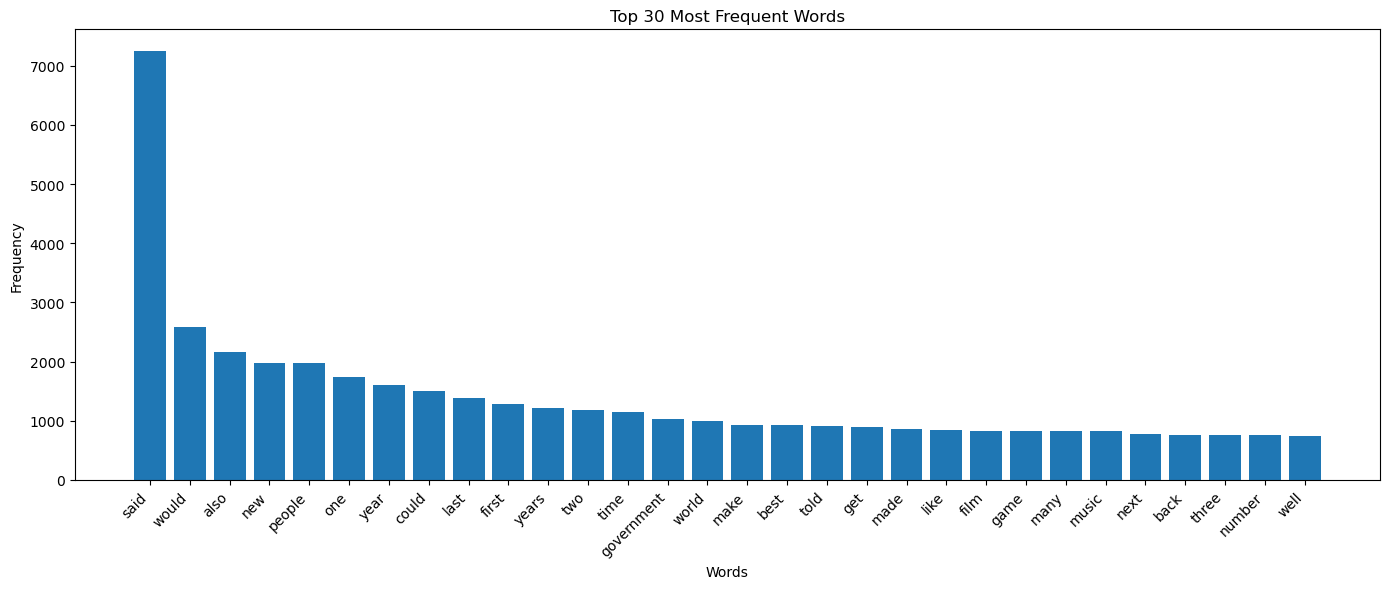

In [116]:
plt.figure(figsize=(14, 6))
plt.bar(top_30_df["word"], top_30_df["freq"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 30 Most Frequent Words")
plt.tight_layout()
plt.show()

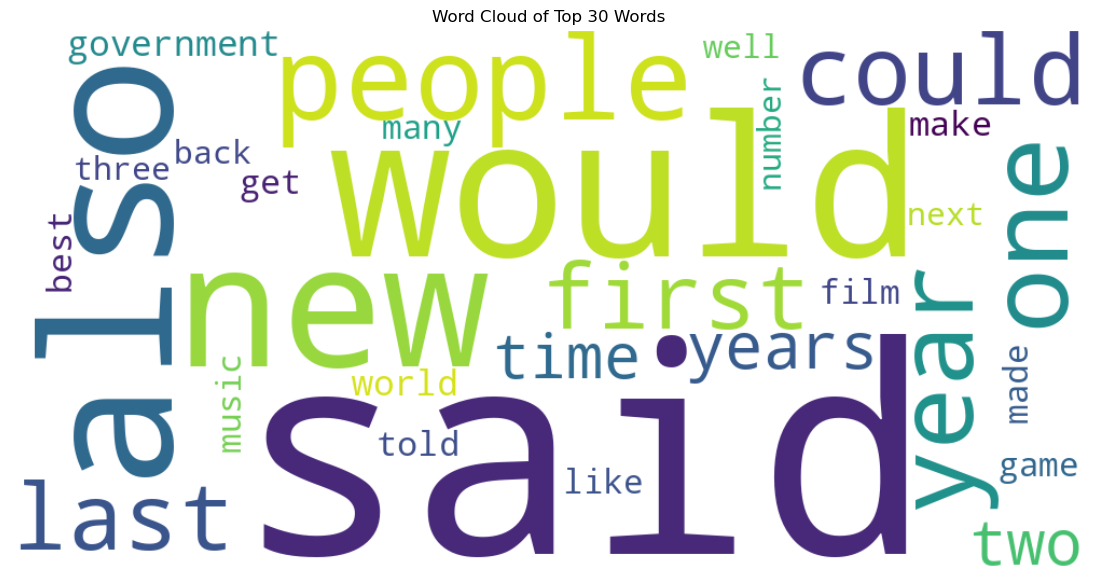

In [117]:
top_30_words = dict(word_count.most_common(30))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(top_30_words)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top 30 Words')
plt.show()

In [118]:
df_words = pd.read_csv("words.csv")

vocab = df_words.iloc[:, 0].astype(str).tolist()

vectorizer = CountVectorizer(vocabulary=vocab, token_pattern=r"(?u)\b\w+\b")

bow_matrix = vectorizer.fit_transform(df["cleaned_text"])

In [119]:
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vocab)
bow_df.head()

,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
0,0,1,0,0,0,0,0,0,0,0,...,0,0,6,0,2,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [120]:
train_bow = bow_df.iloc[:2000]
train_labels  = df['Label'].iloc[:2000]

In [121]:
test_bow = bow_df.iloc[2000:]
test_labels = df['Label'].iloc[2000:]

In [122]:
train_bow.head()

,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
0,0,1,0,0,0,0,0,0,0,0,...,0,0,6,0,2,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [123]:
test_bow.head()

,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
2000,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2001,0,0,2,0,0,0,2,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2002,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2003,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2004,0,0,0,0,2,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


In [127]:
X_train = train_bow.values
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)


In [128]:
U,s,Vt = np.linalg.svd(X_train_scaled,full_matrices=False)

Sigma = np.diag(s)

In [130]:
print(X_train_scaled.shape)
print(U.shape)
print(Sigma.shape)
print(Vt.shape)

(2000, 52)
(2000, 52)
(52, 52)
(52, 52)


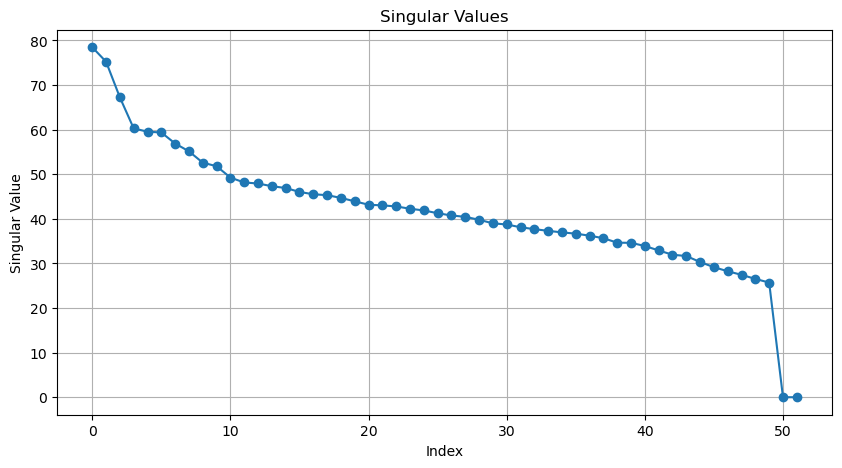

In [136]:
plt.figure(figsize=(10,5))
plt.plot(s,marker='o')
plt.title("Singular Values")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()


In [138]:
print(s)

[7.84795157e+01 7.52305009e+01 6.72255876e+01 6.02756045e+01
 5.95395107e+01 5.93605725e+01 5.68837297e+01 5.51338214e+01
 5.25894064e+01 5.18023892e+01 4.92465184e+01 4.81486119e+01
 4.79237100e+01 4.73141475e+01 4.69132573e+01 4.60311026e+01
 4.55089410e+01 4.53088621e+01 4.46898730e+01 4.39288712e+01
 4.31611956e+01 4.30174052e+01 4.27820152e+01 4.22624337e+01
 4.18803335e+01 4.12578861e+01 4.07510902e+01 4.04494739e+01
 3.97867070e+01 3.89908191e+01 3.87359694e+01 3.81121794e+01
 3.76869009e+01 3.73084557e+01 3.69579823e+01 3.66787294e+01
 3.62195276e+01 3.56553786e+01 3.46520952e+01 3.46200489e+01
 3.39112797e+01 3.29128872e+01 3.19513505e+01 3.16598738e+01
 3.03160103e+01 2.91604213e+01 2.82401482e+01 2.74444543e+01
 2.65290236e+01 2.57076948e+01 5.84957914e-15 5.84957914e-15]


Total components: 50
Optimal k (90% energy): 40
Error at k_90: 0.2990


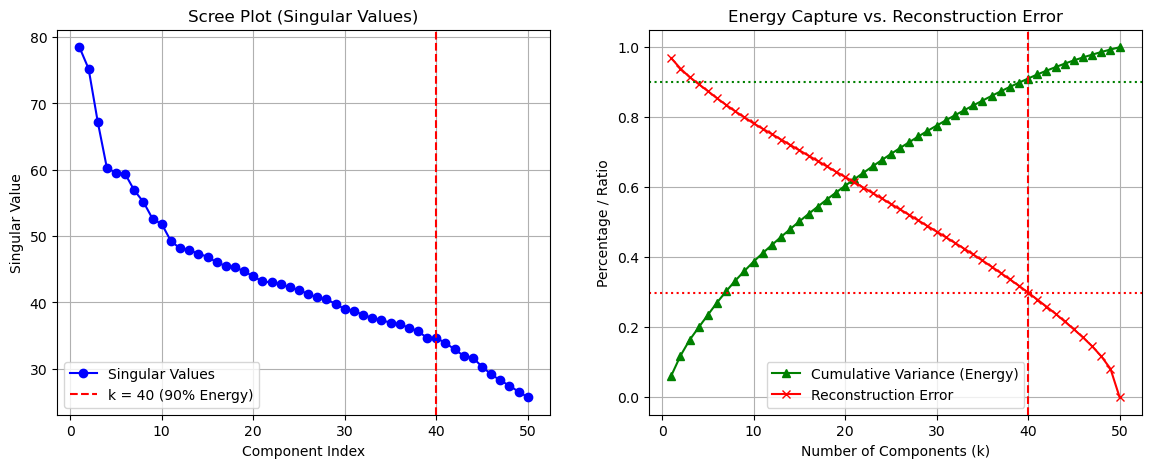

In [140]:
s = s[s > 1e-10]
n_components = len(s)

# محاسبه انرژی انباشته (Cumulative Energy)
energy_cumsum = np.cumsum(s**2) / np.sum(s**2)

# محاسبه خطای بازسازی (Reconstruction Error) فرمول فروبنیوس نسبی
# ||A - A_k||_F^2 = \sum_{i=k+1}^r s_i^2
# ||A||_F^2 = \sum_{i=1}^r s_i^2
# error = sqrt(\sum_{i=k+1}^r s_i^2 / \sum_{i=1}^r s_i^2) = sqrt(1 - energy_cumsum)
recon_error = np.sqrt(1 - energy_cumsum)

# پیدا کردن k برای ۹۰٪ پوشش انرژی
k_90 = np.searchsorted(energy_cumsum, 0.90) + 1
error_at_k_90 = recon_error[k_90 - 1]

print(f"Total components: {n_components}")
print(f"Optimal k (90% energy): {k_90}")
print(f"Error at k_90: {error_at_k_90:.4f}")

# رسم نمودارها
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# نمودار ۱: مقادیر تکین (Scree Plot)
ax1.plot(range(1, n_components + 1), s, 'bo-', label='Singular Values')
ax1.axvline(x=k_90, color='r', linestyle='--', label=f'k = {k_90} (90% Energy)')
ax1.set_title('Scree Plot (Singular Values)')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value')
ax1.grid(True)
ax1.legend()

# نمودار ۲: سهم انرژی انباشته و خطای بازسازی
ax2.plot(range(1, n_components + 1), energy_cumsum, 'g^-', label='Cumulative Variance (Energy)')
ax2.plot(range(1, n_components + 1), recon_error, 'rx-', label='Reconstruction Error')
ax2.axvline(x=k_90, color='r', linestyle='--')
ax2.axhline(y=0.90, color='g', linestyle=':')
ax2.axhline(y=error_at_k_90, color='r', linestyle=':')
ax2.set_title('Energy Capture vs. Reconstruction Error')
ax2.set_xlabel('Number of Components (k)')
ax2.set_ylabel('Percentage / Ratio')
ax2.grid(True)
ax2.legend()
